# Part 1 -2: Set Up and data



In [28]:
!pip install -q gensim datasets scikit-learn matplotlib seaborn  # gensim 4.4+ works with current numpy/scipy; do NOT pin scipy

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
import re, random

import gensim
from gensim.models import Word2Vec
import gensim.downloader as api

random.seed(769); np.random.seed(769)
print("gensim", gensim.__version__)
print("✅ Environment ready")

gensim 4.4.0
✅ Environment ready


### Load and prepare the text

**Yelp reviews**, bounded to 20,000 for a fast lab run (more text = better embeddings —
bump to `train[:50000]` if you have 10 spare minutes). Word2Vec learns from **context**,
so preprocessing is deliberately light: lowercase, letters only, keep word order. Note
what we do NOT do — no stopword removal. "not" is context too (HW3's lesson).


In [29]:
from datasets import load_dataset

dataset = load_dataset("Yelp/yelp_review_full", split="train[:20000]")
df = dataset.to_pandas()
print(f"✅ Loaded {len(df):,} reviews | Columns: {list(df.columns)}")

def preprocess_for_word2vec(text):
    """Lowercase, keep letters only, drop 1-2 char noise. Order preserved."""
    text = re.sub(r"[^a-z\s]", " ", str(text).lower())
    return [t for t in text.split() if len(t) > 2]

corpus = [preprocess_for_word2vec(t) for t in df["text"]]
corpus = [doc for doc in corpus if len(doc) > 5]

all_words = [w for doc in corpus for w in doc]
vocab = Counter(all_words)
print(f"📊 {len(corpus):,} documents | {len(all_words):,} total words | {len(vocab):,} unique")
print("   Top 10:", [w for w, _ in vocab.most_common(10)])

✅ Loaded 20,000 reviews | Columns: ['label', 'text']
📊 19,777 documents | 2,030,369 total words | 38,940 unique
   Top 10: ['the', 'and', 'was', 'for', 'that', 'but', 'you', 'with', 'they', 'this']


## Part 3: Train Word2Vec (8 pts)

Skip-gram (`sg=1`) predicts surrounding words from each center word — slower than CBOW
but better for rarer words, which review vocab is full of. Key dials: `vector_size` (how
much room each word gets), `window` (how far "context" reaches), `min_count` (ignore
words too rare to learn well). One call trains the whole model:


In [30]:
print("🔧 Training Word2Vec (1-2 minutes)...")
model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=10,
                 workers=4, sg=1, epochs=15, seed=769)

print(f"✅ Trained | vocabulary: {len(model.wv):,} words | dims: {model.wv.vector_size}")
vec = model.wv["food"]
print(f"\n'food' vector shape {vec.shape}, first 10 values:\n{vec[:10].round(3)}")

🔧 Training Word2Vec (1-2 minutes)...
✅ Trained | vocabulary: 8,856 words | dims: 100

'food' vector shape (100,), first 10 values:
[-0.163  0.11  -0.129 -0.158 -0.145 -0.021  0.022 -0.059  0.134  0.122]


🧪 Experiment

Retrain with sg=0 (CBOW) into a second variable, model_cbow, and compare model.wv.most_similar('service') vs model_cbow.wv.most_similar('service'). Same corpus, different algorithm — how different are the neighborhoods?
Drop epochs=15 to epochs=2 and retrain. Are the neighbors for 'food' visibly dumber? (Congratulations, you just watched a model underfit.)
Widen window=5 to window=15. Wide windows learn topics rather than syntax — can you see that shift in the neighbor lists?

## Part 4: Word Similarities (8 pts)

The payoff question: **did it learn meaning?** Nearest neighbors should read like a
thesaurus written by your customers. Pair scores give sharper diagnostics — synonyms
high, unrelated pairs low, and watch what happens with good/bad…


In [31]:
test_words = ["good", "bad", "food", "service", "price", "recommend"]
print("📊 NEAREST NEIGHBORS")
for word in test_words:
    if word in model.wv:
        sims = model.wv.most_similar(word, topn=5)
        print(f"\n   '{word}':")
        for w, s in sims:
            print(f"      {w:15} {s:.3f} " + "█" * int(s * 20))
    else:
        print(f"\n   '{word}' not in vocabulary")

print("\n📊 PAIR SIMILARITIES")
pairs = [("good", "great"), ("good", "bad"), ("good", "parking"),
         ("buy", "purchase"), ("fast", "quick")]
for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        s = model.wv.similarity(w1, w2)
        level = "High" if s > 0.5 else "Medium" if s > 0.2 else "Low"
        print(f"   {w1:10} ↔ {w2:10} : {s:6.3f}  ({level})")
    else:
        print(f"   {w1:10} ↔ {w2:10} : (not in vocab)")

📊 NEAREST NEIGHBORS

   'good':
      decent          0.798 ███████████████
      great           0.785 ███████████████
      tasty           0.736 ██████████████
      fantastic       0.687 █████████████
      excellent       0.676 █████████████

   'bad':
      terrible        0.705 ██████████████
      good            0.622 ████████████
      horrible        0.605 ████████████
      meh             0.588 ███████████
      okay            0.565 ███████████

   'food':
      nfood           0.634 ████████████
      service         0.571 ███████████
      fast            0.569 ███████████
      nvalue          0.568 ███████████
      sushi           0.566 ███████████

   'service':
      nservice        0.639 ████████████
      abysmal         0.601 ████████████
      staff           0.600 ███████████
      food            0.571 ███████████
      nvalue          0.565 ███████████

   'price':
      prices          0.767 ███████████████
      cost            0.673 █████████████
      va

### 🧪 Experiment

- Try `model.wv.most_similar('terrible')` — do the neighbors make sense? Now try `'delicious'`, `'overpriced'`, and a slang word like `'yummy'`. Which words did 20k reviews teach well, and which came out half-baked?
- Play odd-one-out: `model.wv.doesnt_match(['pizza', 'sushi', 'taco', 'waiter'])`. Then build a set that YOU think should fool it — does it?
- Add three pairs of your own to `pairs` — one you predict High, one Medium, one Low — and re-run. Score your predictions against the model's.

## Part 5: Document Failures (8 pts)

**This is what separates practitioners from demo-watchers.** Embeddings fail in
predictable ways, and each failure has a business cost:

1. **Rare words** — too few examples to learn from → garbage neighbors (new product
   names, niche jargon).
2. **Polysemy** — one vector per word, so "bar" (drinks) and "bar" (soap) get blended.
3. **Antonyms** — "good" and "bad" appear in identical contexts ("the food was ___"), so
   they end up *similar*. A naive similarity-based sentiment system will confuse
   opposites.

All three hunts are worked below — run them, then design a hunt of your own (that's Q2):

In [32]:
# Hunt 1: RARE WORDS — just above min_count, barely learned
rare_words = [w for w, c in vocab.items() if 10 <= c <= 15 and w in model.wv][:5]
print("1️⃣ RARE WORD TEST (do these neighbors make ANY sense?)")
for word in rare_words:
    neighbors = [w for w, _ in model.wv.most_similar(word, topn=3)]
    print(f"   '{word}' ({vocab[word]} occurrences) → {neighbors}")

# Hunt 2: POLYSEMY — one vector must serve every meaning
print("\n2️⃣ POLYSEMY TEST (which meaning won the blend?)")
for word in ["bar", "order", "star", "cool", "rich"]:
    if word in model.wv:
        print(f"   '{word}' → {[w for w, _ in model.wv.most_similar(word, topn=5)]}")

1️⃣ RARE WORD TEST (do these neighbors make ANY sense?)
   'goldberg' (10 occurrences) → ['physician', 'optometrist', 'symptoms']
   'patronizing' (13 occurrences) → ['unfair', 'ted', 'embarrassed']
   'specialists' (10 occurrences) → ['collections', 'data', 'belongings']
   'drawing' (10 occurrences) → ['acknowledgment', 'articles', 'disregard']
   'financial' (13 occurrences) → ['payments', 'examination', 'preventative']

2️⃣ POLYSEMY TEST (which meaning won the blend?)
   'bar' → ['bars', 'sports', 'patio', 'pub', 'grimy']
   'order' → ['orders', 'ordering', 'ordered', 'togo', 'survey']
   'star' → ['stars', 'rating', 'earn', 'solely', 'ratings']
   'cool' → ['neat', 'chill', 'cute', 'nice', 'rad']
   'rich' → ['glaze', 'ragu', 'complimented', 'creamy', 'peppery']


In [33]:
# Hunt 3: the ANTONYM problem — opposites that live in the same contexts
print("3️⃣ ANTONYM TEST — opposites that live in the same contexts")
antonyms = [("good", "bad"), ("love", "hate"), ("fast", "slow"),
            ("cheap", "expensive"), ("clean", "dirty")]
for w1, w2 in antonyms:
    if w1 in model.wv and w2 in model.wv:
        s = model.wv.similarity(w1, w2)
        flag = "⚠️ TOO SIMILAR!" if s > 0.4 else "✓ OK"
        print(f"   {w1:10} ↔ {w2:10} : {s:.3f} {flag}")

# 4️⃣ One example failure hunt of our own: menu items the model may conflate
print("\n4️⃣ EXAMPLE CUSTOM HUNT — does it separate cuisines or just cluster 'food'?")
for word in ["sushi", "pizza", "taco"]:
    if word in model.wv:
        print(f"   '{word}' → {[w for w, _ in model.wv.most_similar(word, topn=5)]}")
# In the Playground you'll run this hunt on YOUR domain's jargon — predict before you run.

3️⃣ ANTONYM TEST — opposites that live in the same contexts
   good       ↔ bad        : 0.622 ⚠️ TOO SIMILAR!
   love       ↔ hate       : 0.577 ⚠️ TOO SIMILAR!
   fast       ↔ slow       : 0.440 ⚠️ TOO SIMILAR!
   cheap      ↔ expensive  : 0.538 ⚠️ TOO SIMILAR!
   clean      ↔ dirty      : 0.477 ⚠️ TOO SIMILAR!

4️⃣ EXAMPLE CUSTOM HUNT — does it separate cuisines or just cluster 'food'?
   'sushi' → ['sashimi', 'nigiri', 'kim', 'roll', 'ramen']
   'pizza' → ['crust', 'pepperoni', 'pizzas', 'margherita', 'beto']
   'taco' → ['bell', 'tostada', 'tacos', 'tortilla', 'chimichanga']


### 🧪 Experiment

- Change the rare-word band from `10 <= c <= 15` to `100 <= c <= 150`, then `1000+`. At roughly what frequency do neighbors stop being garbage? That's your practical 'minimum mentions' number for trusting an embedding.
- Add two antonym pairs from restaurant life — `('hot','cold')`, `('crowded','empty')` — to the antonym test. Do they flag TOO SIMILAR too?
- Design your OWN failure hunt: pick 3 words you expect the model to confuse (or separate) and print their neighbors. Write your prediction in a comment BEFORE running — keep the misses for Q2.

## Part 6: Business Analogies (6 pts)

`king − man + woman ≈ queen` is vector arithmetic: directions in the space encode
relationships. Does YOUR review-trained space encode business relationships —
quality scales, tense, category membership? First the warm-ups, then three
business-flavored ones with the expected answer written down BEFORE running (that's the
discipline: predict, then test):

In [34]:
def test_analogy(positive_a, negative_b, positive_c, topn=3):
    """Answers: b is to a as ??? is to c   (i.e., a - b + c)."""
    try:
        return model.wv.most_similar(positive=[positive_a, positive_c],
                                     negative=[negative_b], topn=topn)
    except KeyError as e:
        return f"word not in vocabulary: {e}"

print("🧪 WARM-UP ANALOGIES")
for a, b, c in [("better", "good", "bad"),        # hoping for: worse
                ("waitress", "woman", "man"),      # hoping for: waiter
                ("dinner", "night", "morning")]:   # hoping for: breakfast/brunch
    result = test_analogy(a, b, c)
    print(f"\n   {a} - {b} + {c} = ?")
    if isinstance(result, str):
        print("   ", result)
    else:
        for w, s in result:
            print(f"   → {w:15} ({s:.3f})")

🧪 WARM-UP ANALOGIES

   better - good + bad = ?
   → worse           (0.581)
   → nicer           (0.515)
   → desirable       (0.491)

   waitress - woman + man = ?
   → waiter          (0.736)
   → server          (0.707)
   → bartender       (0.575)

   dinner - night + morning = ?
   → lunch           (0.650)
   → breakfast       (0.580)
   → brunch          (0.542)


In [35]:
my_analogies = [
    ("worst", "bad", "good"),        # expecting: best  (quality superlative)
    ("lunch", "noon", "evening"),    # expecting: dinner (meal ↔ time of day)
    ("beer", "bar", "coffee"),       # expecting: cafe  (drink ↔ venue)
]
for a, b, c in my_analogies:
    result = test_analogy(a, b, c)
    print(f"\n   {a} - {b} + {c} = ?")
    if isinstance(result, str):
        print("   ", result)
    else:
        for w, s in result:
            print(f"   → {w:15} ({s:.3f})")
# Expect a mixed scorecard — a 20k-review corpus encodes some relationships crisply
# and mangles others. Explaining WHICH and WHY is the actual deliverable.


   worst - bad + good = ?
   → best            (0.758)
   → excellent       (0.599)
   → fantastic       (0.578)

   lunch - noon + evening = ?
   → dinner          (0.674)
   → getaway         (0.499)
   → celebration     (0.489)

   beer - bar + coffee = ?
   → coffees         (0.599)
   → tea             (0.575)
   → brewed          (0.552)


🧪 Experiment


*   Write 3 analogies of your own — think roles (waiter:restaurant :: barista:?), categories (pizza:italian :: taco:?), sentiment (love:like :: hate:?). Comment your predicted answer BEFORE running each; keep the misses, they're Q3 gold.

*   Bump topn=3 to topn=10 on an analogy that 'failed'. Is the answer you hoped for lurking at rank 6? What does that say about how confidently you should use rank-1 answers?

*   Try the famous one: test_analog ('king', 'man', 'woman'). Yelp reviewers rarely discuss royalty — what does the miss teach you about corpus coverage?

## Part 7: Compare Pre-trained (4 pts)

Your model knows 20,000 Yelp reviews; **GloVe** (`glove-twitter-50`) was trained on 2
billion tweets. Same word, different worlds — this is the classic build-vs-buy question
for embeddings.

⚠️ **Heads-up:** the GloVe download is **~200MB** — takes a couple of minutes on Colab
the first time.


In [36]:
print("📥 Downloading glove-twitter-50 (~200MB, one-time)...")
glove = api.load("glove-twitter-50")
print(f"✅ Loaded | vocabulary: {len(glove.key_to_index):,} words")

print("\n📊 YOUR YELP MODEL vs GLOVE-TWITTER")
for word in ["good", "service", "price", "recommend"]:
    yours = [w for w, _ in model.wv.most_similar(word, topn=5)] if word in model.wv else "(not in vocab)"
    theirs = [w for w, _ in glove.most_similar(word, topn=5)] if word in glove else "(not in vocab)"
    print(f"\n   '{word}'")
    print(f"      Your Word2Vec: {yours}")
    print(f"      GloVe/Twitter: {theirs}")

📥 Downloading glove-twitter-50 (~200MB, one-time)...
✅ Loaded | vocabulary: 1,193,514 words

📊 YOUR YELP MODEL vs GLOVE-TWITTER

   'good'
      Your Word2Vec: ['decent', 'great', 'tasty', 'fantastic', 'excellent']
      GloVe/Twitter: ['well', 'great', 'too', 'nice', 'better']

   'service'
      Your Word2Vec: ['nservice', 'abysmal', 'staff', 'food', 'nvalue']
      GloVe/Twitter: ['services', 'office', 'client', 'customer', 'company']

   'price'
      Your Word2Vec: ['prices', 'cost', 'value', 'quality', 'reasonable']
      GloVe/Twitter: ['prices', 'discount', 'cost', 'buy', 'limited']

   'recommend'
      Your Word2Vec: ['highly', 'suggest', 'heartbeat', 'advise', 'recommended']
      GloVe/Twitter: ['suggest', 'consider', 'interested', 'discover', 'simply']


### 🧪 Experiment

- Compare the two models on `'sick'` — on Twitter it's often slang for *great*; in restaurant reviews it means food poisoning. Whose neighbors reflect which meaning?
- GloVe was trained on enough text for the classic to work: try `glove.most_similar(positive=['king','woman'], negative=['man'])`. Now you've seen the same math succeed and fail — what was the difference?
- Pick a restaurant-specific word (`'appetizer'`, `'reservation'`) and compare. Where does your small specialist beat the giant generalist?


**Pause and look (feeds Q4):** your model's neighbors should smell like restaurants;
GloVe's like Twitter. Neither is "better" — one is specialized, one is general. Which
would you deploy for a restaurant-review dashboard, and which for a generic chatbot?

### Bonus (ungraded): see your embedding space

t-SNE squashes 100 dimensions to 2 so you can look for neighborhoods (food words, service
words, sentiment words). Note `max_iter=` — sklearn ≥1.5 removed the old `n_iter=` name.


Running t-SNE (~30 seconds)...


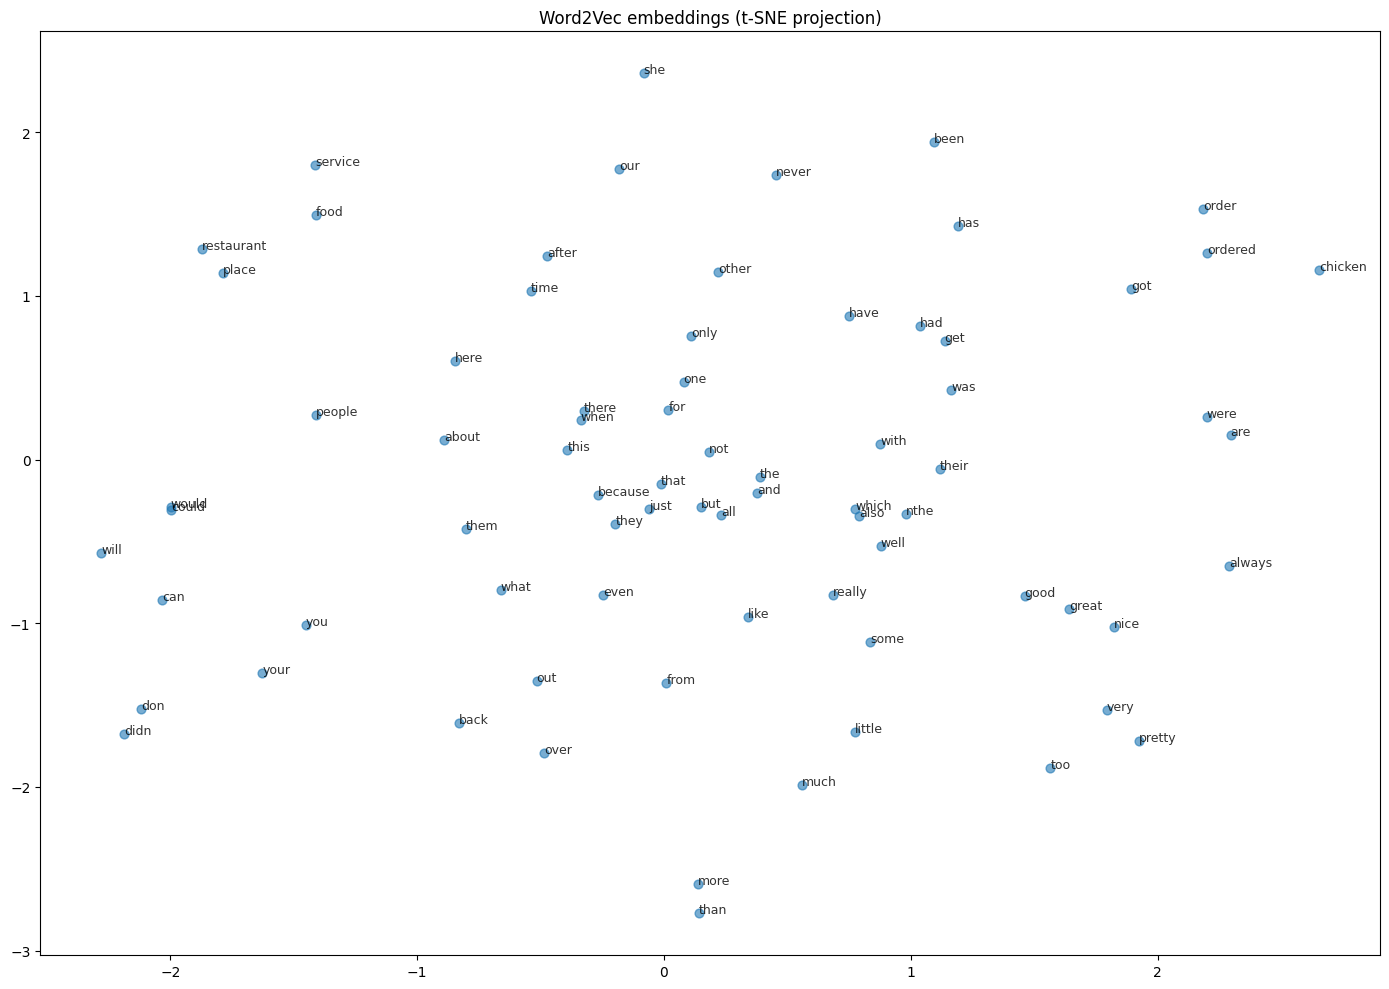

In [37]:
from sklearn.manifold import TSNE

top_words = [w for w, _ in vocab.most_common(150) if w in model.wv][:75]
vectors = np.array([model.wv[w] for w in top_words])

print("Running t-SNE (~30 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=769, max_iter=1000)  # sklearn>=1.5: max_iter, not n_iter
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=40)
for i, word in enumerate(top_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9, alpha=0.8)
plt.title("Word2Vec embeddings (t-SNE projection)")
plt.tight_layout()
plt.show()

## 🎮 Your Domain Playground

Now train Word2Vec on a corpus from a world **you** know cold — and be the judge of what
it learned. Sneakerhead forum posts, game reviews from YOUR genre, song lyrics, F1 race
threads, job postings in your industry, your company's support tickets. This is where
custom embeddings earn their keep: a generic model has never seen your world's jargon,
but you have — so you can tell instantly whether "neighbors" are insight or noise.

You'll want **thousands of documents** of real language (10k+ is great; below ~2k the
vectors get shaky — smaller corpora work, just expect rougher neighbors and say so).

1. **Load your corpus.** Pick ONE loader and adapt:


# loading hugging face dataset

In [38]:
# libraries
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [39]:
df = load_dataset("auphong2707/game-reviews-sentiment", split="train[:20000]").to_pandas()
print(df.columns)
#my_text_column = "review_text"   # set to the real column name — print(my_df.columns) first!

Index(['review_text', 'review_score', 'review_category'], dtype='object')


In [40]:
my_text_column = "review_text"

In [41]:
# training
# Reuses preprocess_for_word2vec from Part 1-2
my_corpus = [preprocess_for_word2vec(t) for t in df[my_text_column]]
my_corpus = [doc for doc in my_corpus if len(doc) > 5]

my_vocab = Counter(w for doc in my_corpus for w in doc)
print(f"📊 {len(my_corpus):,} documents | {len(my_vocab):,} unique words")

my_model = Word2Vec(sentences=my_corpus, vector_size=100, window=5,
                    min_count=5, workers=4, sg=1, epochs=15, seed=769)
print(f"✅ Trained | vocabulary: {len(my_model.wv):,} words")

📊 19,911 documents | 35,976 unique words
✅ Trained | vocabulary: 11,516 words


In [42]:
# settings words
game_words = ["gameplay", "graphics", "story", "multiplayer", "buggy", "grind"]

print("📊 GAME REVIEW NEAREST NEIGHBORS")
for word in game_words:
    if word in my_model.wv:
        print(f"\n   '{word}' ({my_vocab[word]} occurrences):")
        for w, s in my_model.wv.most_similar(word, topn=5):
            print(f"      {w:15} {s:.3f} " + "█" * int(s * 20))
    else:
        print(f"\n   '{word}' not in vocabulary")

📊 GAME REVIEW NEAREST NEIGHBORS

   'gameplay' (5010 occurrences):
      combat          0.688 █████████████
      brillant        0.669 █████████████
      gamplay         0.667 █████████████
      voiceacting     0.647 ████████████
      game            0.613 ████████████

   'graphics' (4027 occurrences):
      visuals         0.825 ████████████████
      graphic         0.708 ██████████████
      musics          0.660 █████████████
      excelent        0.651 █████████████
      cel             0.642 ████████████

   'story' (8450 occurrences):
      storyline       0.830 ████████████████
      plot            0.824 ████████████████
      voiceacting     0.688 █████████████
      narrative       0.670 █████████████
      elaborated      0.652 █████████████

   'multiplayer' (1675 occurrences):
      campaign        0.797 ███████████████
      singleplayer    0.729 ██████████████
      warzone         0.717 ██████████████
      extinction      0.701 ██████████████
      coop        

In [43]:
# Hunt 1: RARE WORDS — just above min_count, barely learned
random.seed(769)
candidates = [w for w, c in my_vocab.items() if 5 <= c <= 10 and w in my_model.wv]
rare_words = random.sample(candidates, 5)

print("1️⃣ RARE WORD TEST (do these neighbors make ANY sense?)")
for word in rare_words:
    neighbors = [w for w, _ in my_model.wv.most_similar(word, topn=3)]
    print(f"   '{word}' ({my_vocab[word]} occurrences) → {neighbors}")

1️⃣ RARE WORD TEST (do these neighbors make ANY sense?)
   'som' (5 occurrences) → ['hitbox', 'imperfect', 'ctd']
   'est' (9 occurrences) → ['vel', 'mais', 'jogo']
   'bee' (10 occurrences) → ['shirt', 'overview', 'intercept']
   'capped' (6 occurrences) → ['geforce', 'disabling', 'latency']
   'unprecedented' (7 occurrences) → ['transcends', 'elevate', 'captivates']


In [44]:
# Hunt 2: POLYSEMY — one vector must serve every meaning
for word in ["grind", "farm", "camp", "tank", "carry", "boss"]:
    if word in my_model.wv:
        print(f"   '{word}' → {[w for w, _ in my_model.wv.most_similar(word, topn=5)]}")
    else:
        print(f"   '{word}' not in vocabulary")

   'grind' → ['grinding', 'tokens', 'redundant', 'repetative', 'dailies']
   'farm' → ['materials', 'currency', 'stash', 'squid', 'farming']
   'camp' → ['camps', 'designated', 'prisoners', 'waits', 'spawns']
   'tank' → ['paladin', 'rockets', 'piloting', 'pistols', 'choppers']
   'carry' → ['recharges', 'accessed', 'plow', 'pouches', 'alignment']
   'boss' → ['fights', 'bosses', 'fight', 'phases', 'battles']


In [45]:
# Hunt 3: the ANTONYM problem — opposites that live in the same contexts
# prediction: good/bad and love/hate flag TOO SIMILAR; easy/hard may too
antonyms = [("good", "bad"), ("love", "hate"), ("easy", "hard"),
            ("fun", "boring"), ("fast", "slow"), ("worth", "waste")]
for w1, w2 in antonyms:
    if w1 in my_model.wv and w2 in my_model.wv:
        s = my_model.wv.similarity(w1, w2)
        flag = "⚠️ TOO SIMILAR!" if s > 0.4 else "✓ OK"
        print(f"   {w1:10} ↔ {w2:10} : {s:.3f} {flag}")
    else:
        print(f"   {w1:10} ↔ {w2:10} : (not in vocab)")

   good       ↔ bad        : 0.741 ⚠️ TOO SIMILAR!
   love       ↔ hate       : 0.628 ⚠️ TOO SIMILAR!
   easy       ↔ hard       : 0.758 ⚠️ TOO SIMILAR!
   fun        ↔ boring     : 0.476 ⚠️ TOO SIMILAR!
   fast       ↔ slow       : 0.511 ⚠️ TOO SIMILAR!
   worth      ↔ waste      : 0.467 ⚠️ TOO SIMILAR!


# Insider Test:

- Did the model learn things a generic model wouldn't know?
  - Yes. It picked up gamer jargon that a general model would miss or get wrong: 'buggy' sits next to glitchy, laggy, and bugged, 'grind' pulls in tokens, dailies, and loot, 'boss' maps to fights, phases, and bosses, and 'farm' means gathering materials rather than agriculture. It also learned brand-level knowledge, since 'multiplayer' landed beside the Call of Duty modes and games, and 'tank' pulled in paladin and frag, so it knows the role and the shooter sense of the word.

- Where did it embarrass itself, and explain the failure using Part 5's three categories?
  - The struggle for rare words were mostly mispellings. The polysemy had issues where words for gmaing slang lost out to real world definitions such as camping. In gaming camping is referred to as sitting in one area waiting to ambush other players. The last category of antonymd, the six main words all flagged as too similar making senitment difficult. One example of this is good and bad which flagged at .738.

- Compare against the Yelp demo run: which corpus produced the more trustworthy space, and why?
  - Yelp did better to be trust worthy. I believe the implicit context of the review itself is what lead to Yelp being better. Wheh writing a food rview typically a reviewer will use more descriptive words, clearer uses of sarcasm so sentiment doesnt not get lost in noise, and there is generally less niche slang. Gaming reviews are often shorter written only by a particualr subset of people. The gaming review is written for gamers while the yelp review is written for a more general audience. The lack of domain specificity helps Yelp in this case verse the gaming reviews.

## 🤔 Debrief

1. A teammate proposes using your Word2Vec similarities to route customer complaints
("angry" reviews to escalation). Given the **antonym problem** you documented, what's the failure mode, and what would you check before shipping?
    - The failure is opposite words get bundled together. This leaves a gap for actual poor reviews slipping through the cracks is someone is just dismissing nosie. I would cross the segment getting filtered out with the rating as well. TArue poor reviews will have poor ratings and liekwise good reviews will have higher ratings. This method allows you to focus on the lower star ratings.

2. When is training your own embeddings worth it versus using pre-trained (or just
calling a sentence-embedding API)? Think data volume, domain jargon, and maintenance
cost — who retrains this model when the menu changes?
  - Training your own makes sense with niche jargon sets where more context then generally avaailble is need for a standard model. Also if the dataset is small, like less than 10K a more bespoke training makes sense from a compute cost and time of iteration lense. Smaller sets train quickly compared to chucking the set into a generic model and having to verify and validate the outputs constantly. Doing the bespoke solution with more up front work saves time and money most likely. Ownership which is the biggest thing as it related to production or business use comes down to techincal ability. If this was a customer servcie/ops team then liekly this should be maintained by the IT or data team. Even if the CX team has a techincal person, leaving a single point of failure would negatiely harm the business if this perosn leaves. Ideally the technical perosn from the CX team just transfers to IT or the data team. This person will have the business nknowledge that normally is just tribal knowledge so further business asks are less likely to get lost in translations or requirements for further iteration can be better fine tuned for resources.


# HW Answers

Q1: Which similarities made sense? Which surprised you?

A1: Story story line, graphics, visuals, and buggy all made sense. This would be typical conversion of gamer. What surpised me was the good and bad scoring long with grind. Gamers typically have good problem solving skills so one would hope that would translate to higher vocabulary, it did not though. The grind value also was a surprise because of how grind can be used. The lack of specificaity for context of grind probably did contribute a bit to its matching to loot and such.

Q2: Document an embedding failure: what happened and why?


A2: The embedding failure is the antonym check. All my words choosen got flagged. Word2Vec learns from sorounding meanings so the word selction by mean and the words being very similar likely would confuse the model or at the very least harm accuracy. I think since the antonyms were used is very simialr context that was the main negative impact.


Q3: Which analogies worked? Why do some fail?


A3: The better analogies are ones that have frequent and clear patterns. One example is worst and bad or good and best. I believ one of the reasons for a higher failure would be inconsistent patterns of use. This wouldbe common with sarcasm in the review. So phrases like "this was a great time" while the review has a one star may miss the sarcasm of the review.


Q4: How do your embeddings differ from pre-trained ones?


A4: The real difference is the domain context. Yelp was much more patterened so the model had better results compared to the gaming set where certain patterns impacted the quality of results. One other thing to note is the size of the datasets. My gaming data has much more data so there could have been a more over represented issue. If the yelp data had a similar size the same kind of result could have been possible. My gaming data also had some words that were more jargon that what likely would have been in the Yelp set.

I used Claude Sonnet 5 for some assitance with the code. and debugging.